# Physics-Informed MSCNN: Neural Networks with Physics Regularization

This notebook explains how the **PhysicsInformedMSCNN** model implements a Physics-Informed Neural Network (PINN) for solar atmospheric inversion. Unlike standard supervised learning, this approach combines:

1. **Supervised loss**: MSE between network predictions and MURaM atmospheric parameters
2. **Physics regularization**: Constraints from physical approximations (WFA for B_LOS, Doppler for V_LOS)

The key innovation is leveraging MURaM MHD simulations to provide **ground truth at optimal optical depths**, where physical approximations best match the actual atmospheric parameters.


## 1. Import Required Libraries


In [2]:
import sys
import numpy as np
from pathlib import Path

sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/")
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/")
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/models/")

import torch
import torch.nn as nn
import torch.optim as optim
import astropy.units as u
import matplotlib.pyplot as plt

from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.physics_utils import ApproxInversions
from utils.muram_data import MhdData, StokesData

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: False


## 2. Instantiate the PhysicsInformedMSCNN Model

The `PhysicsInformedMSCNN` extends the standard `MSCNNInversionModel` with physics-aware training capabilities. Key parameters control the physics regularization:

- **central_wavelength**: Rest wavelength of the spectral line (e.g., 6301.5 Å for Fe I)
- **lande_factor**: Landé g-factor for the line (~1.67 for Fe I 6301.5)
- **wl_range**: Wavelength indices to use for WFA/Doppler calculations
- **lambda_reg**: Weight balancing supervised loss vs physics regularization (0.0 = pure supervised, 1.0 = strong physics)
- **use_physics**: Controls which physics regularization to apply:
  - `None`: No physics regularization (pure supervised learning)
  - `'wfa'`: Only WFA B_LOS regularization
  - `'doppler'`: Only Doppler V_LOS regularization
  - `'both'`: Both WFA and Doppler regularization (default)

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the Physics-Informed MSCNN model
model = PhysicsInformedMSCNN(
    scales=[1, 2, 3],                           # Multi-scale coarse-graining
    in_channels=2,                              # I and V Stokes parameters
    c1_filters=16,                              # Filters in first conv block
    c2_filters=32,                              # Filters in second conv block
    kernel_size=5,                              # Convolution kernel size
    pool_size=2,                                # MaxPool kernel size
    n_linear_layers=4,                          # Dense layers for final mapping
    output_features=3*21,                       # 3 parameters × 21 heights = 63 outputs
    input_length=112,                           # Spectral dimension of Stokes profiles
    
    # Physics-informed parameters
    central_wavelength=6301.5*u.Angstrom,      # Fe I 6301.5 Å
    lande_factor=1.67,                          # Landé g-factor
    wl_range=(15, 60),                          # Wavelength indices for WFA/Doppler
    lambda_reg=0.1,                             # Regularization weight
    use_physics='both',                         # Use both WFA and Doppler (can be None, 'wfa', 'doppler', or 'both')

    # Dropout for uncertainty
    dropout_rate=0.2  # 20% dropout
).to(device)

print(f"Model instantiated on {device}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Regularization weight (lambda_reg): {model.lambda_reg}")
print(f"Physics mode: {model.use_physics}")

Using device: cpu
Model instantiated on cpu
Total trainable parameters: 7,318,223
Regularization weight (lambda_reg): 0.1
Physics mode: both


## 3. Understanding the Physics-Informed Loss Function

The loss combines two components:

$$\mathcal{L}_{\text{total}} = \underbrace{\text{MSE}(\hat{y}, y)}_{\text{supervised}} + \lambda_{\text{reg}} \cdot \underbrace{\left(\text{MSE}\big(B_{\text{LOS}}^{\text{WFA}}, B_z^{\text{pred}}(h^*)\big) + \text{MSE}\big(v_{\text{LOS}}^{\text{Doppler}}, v_z^{\text{pred}}(h^*)\big)\right)}_{\text{physics regularization}}$$

Where:
- $\hat{y}$: Network predictions (atmospheric parameters at 21 heights)
- $y$: Ground truth from MURaM simulations
- $B_{\text{LOS}}^{\text{WFA}}$: Weak-Field Approximation magnetic field from Stokes profiles
- $v_{\text{LOS}}^{\text{Doppler}}$: Doppler-shift velocity from Stokes profiles
- $B_z^{\text{pred}}(h^*)$ and $v_z^{\text{pred}}(h^*)$: Model-predicted magnetic field and velocity at the best-matching optical depth $h^*$

Height selection $h^*$ is determined by minimizing RRMSE between the approximation and the MHD cubes across heights; the mismatch is then computed against the model's predictions at that height.

## 4. Data Preparation: Loading MURaM Simulations

First, we need to load MHD and Stokes data from MURaM simulations. The `MhdData` and `StokesData` classes handle this:


In [4]:
# Data paths (adjust to your system)
data_path = Path("/scratchsan/observatorio/juagudeloo/data/")
step = 112  # Choose a simulation step

# Load MHD data and remap to optical depth
mhd = MhdData(
    data_path=data_path / "muram-simulation",
    nx=480, ny=480, nz=256
)
mhd.load_step(step=step, z_max=250)
mhd.load_opacity_table(kappa_path=data_path / "csv/kappa.0.dat")
mhd.compute_optical_depth(dz=10*u.km)

# Create a uniform log(tau) grid for remapping
new_logtau = np.arange(-2.0, 0.1, 0.1)
mhd.remap_to_optical_depth(new_logtau, quantities=["T", "Vz", "Bz"])

print(f"MHD data loaded: {mhd.od_data['Bz'].shape}")
print(f"Log(tau) values: {new_logtau}")

# Load Stokes data
stokes = StokesData(
    data_dir=data_path / "muram-simulation/",
    step=step,
    wavelength_range=(6300.5, 6303.5),
    wavelength_step=0.01
)
stokes.load_stokes()
stokes.continuum_normalization(cont_indices=[0, 1, 2, 3])
stokes.load_hinode_lsf(data_path / "hinode-MODEST/PSFs/hinode_sp.spline.psf")
stokes.apply_spectral_convolution()
stokes.resample_to_hinode()

print(f"Stokes data loaded: {stokes.data['I'].shape}")
print(f"Stokes wavelength range: {stokes.wl.min():.2f} - {stokes.wl.max():.2f} Å")

Loading step 112000


  Trimmed z axis to first 250 layers (0..249)
  Reference layer (T ~ 5780 K) at z-index 186
  Done.
Opacity interpolator loaded from /scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat
  T range: [3.320, 5.300] (log10 K)
  P range: [-2.000, 8.000] (log10 dyne/cm²)
Computing optical depth...
  Optical depth computed.
Remapping to optical depth coordinates (21 levels)...
  Processing T
  Processing Vz
  Processing Bz
  Remapping complete.
MHD data loaded: (480, 480, 21)
Log(tau) values: [-2.00000000e+00 -1.90000000e+00 -1.80000000e+00 -1.70000000e+00
 -1.60000000e+00 -1.50000000e+00 -1.40000000e+00 -1.30000000e+00
 -1.20000000e+00 -1.10000000e+00 -1.00000000e+00 -9.00000000e-01
 -8.00000000e-01 -7.00000000e-01 -6.00000000e-01 -5.00000000e-01
 -4.00000000e-01 -3.00000000e-01 -2.00000000e-01 -1.00000000e-01
  1.77635684e-15]
Loading Stokes data from /scratchsan/observatorio/juagudeloo/data/muram-simulation/stokes_112000.npy
  I shape: (480, 480, 300)
  Q shape: (480, 480, 300)
  U sha

## 5. Compute WFA-based B_LOS Approximation

The Weak-Field Approximation (WFA) relates Stokes V to the line-of-sight magnetic field:

$$V \approx -\frac{e}{4\pi m_e c} \lambda_0^2 g_\lambda B_{\text{LOS}} \frac{dI}{d\lambda}$$

The `ApproxInversions` class solves this using least-squares fitting to estimate $B_{\text{LOS}}$ from observations.


<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1108217/1536430159.py:27: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'MHD $B_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')


B_LOS (WFA) computed: shape (480, 480), range [-527.4 G, 560.1 G]


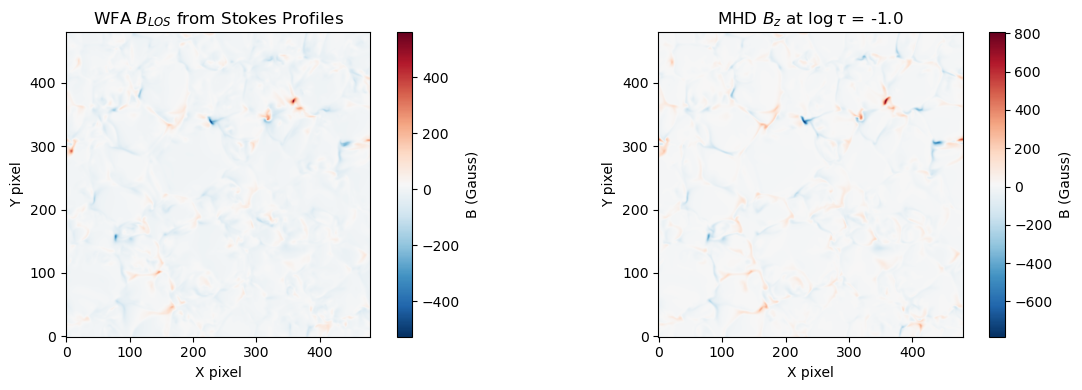

In [5]:
# Create ApproxInversions object
inversions = ApproxInversions(
    stokes=stokes.data,
    wavelength=stokes.wl,
    central_wavelength=6301.5*u.Angstrom,
    lande_factor=1.67
)

# Compute B_LOS using WFA
blos = inversions.compute_blos_wfa(wl_range=[15, 60])
print(f"B_LOS (WFA) computed: shape {blos.shape}, range [{blos.min():.1f}, {blos.max():.1f}]")

# Visualize B_LOS map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# WFA B_LOS
im0 = axes[0].imshow(blos.value, origin='lower', cmap='RdBu_r')
axes[0].set_title('WFA $B_{LOS}$ from Stokes Profiles')
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im0, ax=axes[0], label='B (Gauss)')

# MHD Bz at a reference height (middle of optical depth range)
ref_height = len(new_logtau) // 2
mhd_bz_ref = mhd.od_data['Bz'].value[:, :, ref_height]
im1 = axes[1].imshow(mhd_bz_ref, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'MHD $B_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[1], label='B (Gauss)')

plt.tight_layout()
plt.show()

## 6. Compute Doppler-based V_LOS Approximation

The Doppler formula relates wavelength shift to velocity:

$$v_{\text{LOS}} = \frac{\Delta \lambda}{\lambda_0} c$$

where $\Delta \lambda$ is found by interpolating the zero-crossing of Stokes V.


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1108217/139116735.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'MHD $v_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')


V_LOS (Doppler) computed: shape (480, 480), range [-33.5 km / s, 10.5 km / s]


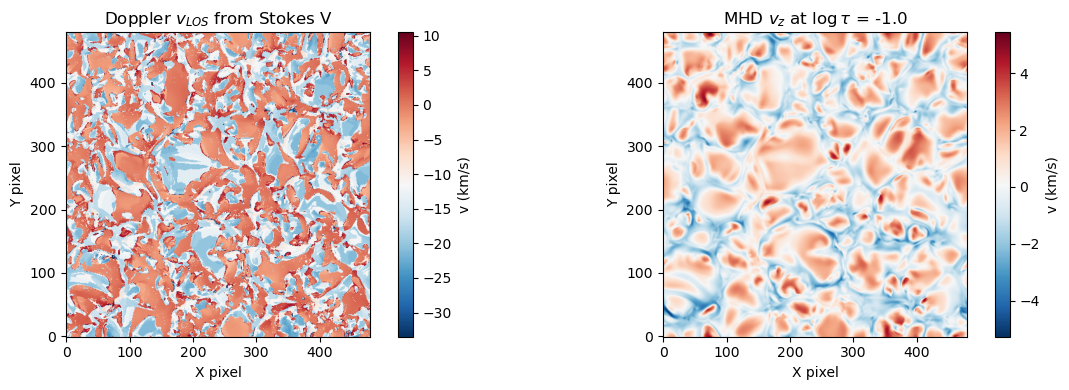

In [6]:
# Compute V_LOS using Doppler shift
vlos = inversions.compute_vlos_doppler(wl_range=[15, 60])
print(f"V_LOS (Doppler) computed: shape {vlos.shape}, range [{vlos.min():.1f}, {vlos.max():.1f}]")

# Visualize V_LOS map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Doppler V_LOS
im0 = axes[0].imshow(vlos.value, origin='lower', cmap='RdBu_r')
axes[0].set_title('Doppler $v_{LOS}$ from Stokes V')
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im0, ax=axes[0], label='v (km/s)')

# MHD Vz at a reference height
mhd_vz_ref = mhd.od_data['Vz'].value[:, :, ref_height]
im1 = axes[1].imshow(mhd_vz_ref, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'MHD $v_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[1], label='v (km/s)')

plt.tight_layout()
plt.show()

## 7. Find Best Matching Optical Depth Height

The key innovation: instead of using a fixed height, we find which optical-depth slice in the MHD cube **best matches** each approximation using Relative Root Mean Square Error (RRMSE):

$$\text{RRMSE}(h) = \frac{\sqrt{\frac{1}{N}\sum_{i,j}(A_{i,j} - M_{i,j}(h))^2}}{\text{mean}(|M_{i,j}(h)|)}$$

where $A$ is the approximation (WFA or Doppler) and $M(h)$ is the MHD data at height $h$.


Best matching height for B_LOS: log(τ) = -1.20 (RRMSE = 1.1470)
Best matching height for V_LOS: log(τ) = 0.00 (RRMSE = 6.2702)


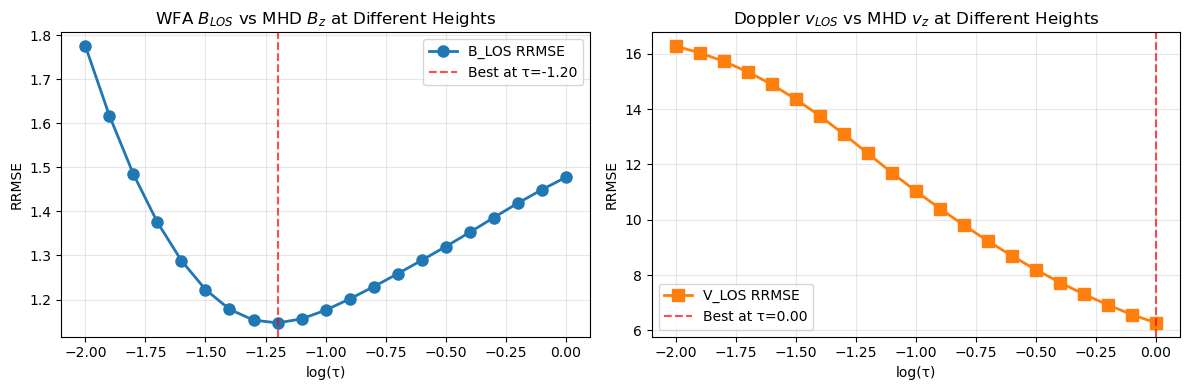

In [7]:
# Compute RRMSE for B_LOS at all optical depths
blos_np = blos.value
mhd_bz = mhd.od_data['Bz'].value
mhd_vz = mhd.od_data['Vz'].value

blos_rrmse = []
vlos_rrmse = []

for k in range(mhd_bz.shape[2]):
    # RRMSE for B_LOS
    rmse_b = np.sqrt(np.mean((blos_np - mhd_bz[:, :, k]) ** 2))
    rrmse_b = rmse_b / (np.mean(np.abs(mhd_bz[:, :, k])) + 1e-8)
    blos_rrmse.append(rrmse_b)
    
    # RRMSE for V_LOS
    rmse_v = np.sqrt(np.mean((vlos.value - mhd_vz[:, :, k]) ** 2))
    rrmse_v = rmse_v / (np.mean(np.abs(mhd_vz[:, :, k])) + 1e-8)
    vlos_rrmse.append(rrmse_v)

blos_rrmse = np.array(blos_rrmse)
vlos_rrmse = np.array(vlos_rrmse)

# Find best heights
best_blos_idx = np.argmin(blos_rrmse)
best_vlos_idx = np.argmin(vlos_rrmse)

best_blos_logtau = new_logtau[best_blos_idx]
best_vlos_logtau = new_logtau[best_vlos_idx]

print(f"Best matching height for B_LOS: log(τ) = {best_blos_logtau:.2f} (RRMSE = {blos_rrmse[best_blos_idx]:.4f})")
print(f"Best matching height for V_LOS: log(τ) = {best_vlos_logtau:.2f} (RRMSE = {vlos_rrmse[best_vlos_idx]:.4f})")

# Plot RRMSE vs optical depth
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(new_logtau, blos_rrmse, 'o-', linewidth=2, markersize=8, label='B_LOS RRMSE')
axes[0].axvline(best_blos_logtau, color='red', linestyle='--', alpha=0.7, label=f'Best at τ={best_blos_logtau:.2f}')
axes[0].set_xlabel('log(τ)')
axes[0].set_ylabel('RRMSE')
axes[0].set_title('WFA $B_{LOS}$ vs MHD $B_z$ at Different Heights')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(new_logtau, vlos_rrmse, 's-', linewidth=2, markersize=8, label='V_LOS RRMSE', color='C1')
axes[1].axvline(best_vlos_logtau, color='red', linestyle='--', alpha=0.7, label=f'Best at τ={best_vlos_logtau:.2f}')
axes[1].set_xlabel('log(τ)')
axes[1].set_ylabel('RRMSE')
axes[1].set_title('Doppler $v_{LOS}$ vs MHD $v_z$ at Different Heights')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Calculate Physics Regularization Term

Note: For this walkthrough we use a small spatial patch to keep runtimes short. This is only for demonstration; you can run the same logic on the full field when not constrained by time.

The model's `physics_regularization()` method:
1. Computes WFA $B_{\text{LOS}}$ and Doppler $v_{\text{LOS}}$ from input Stokes (here, a patch)
2. Finds the optical-depth height with lowest RRMSE for each (using MHD cubes on the same patch)
3. Compares approximations to the model's predicted $B_z$ and $v_z$ at those optimal heights
4. Returns MSE values as the regularization term

In [8]:
# Demonstrate physics_regularization (step by step) with model predictions on a patch
# This mirrors what happens internally when compute_loss is called

# Patch selection (4x4 region)
y0, x0 = 100, 200
H, W = 4, 4

# Step 1: Extract Stokes patch and wavelength
stokes_patch_I = stokes.data['I'][y0:y0+H, x0:x0+W, :]
stokes_patch_V = stokes.data['V'][y0:y0+H, x0:x0+W, :]
stokes_patch = {
    'I': stokes_patch_I,
    'V': stokes_patch_V,
}
wl_array = stokes.wl

# Step 2: Create ApproxInversions on the patch (approximations computed once)
inv = ApproxInversions(
    stokes=stokes_patch,
    wavelength=wl_array,
    central_wavelength=model.central_wavelength,
    lande_factor=model.lande_factor,
)
blos_map = inv.compute_blos_wfa(wl_range=model.wl_range).value
vlos_map = inv.compute_vlos_doppler(wl_range=model.wl_range).value

# Step 3: Build MHD patch cubes for height selection
mhd_bz_patch = mhd.od_data['Bz'].value[y0:y0+H, x0:x0+W, :]
mhd_vz_patch = mhd.od_data['Vz'].value[y0:y0+H, x0:x0+W, :]

# Step 4: Find best-matching heights via RRMSE against MHD patch
bz_idx, bz_rrmse_full = model._best_rrmse_index(blos_map, mhd_bz_patch)
vz_idx, vz_rrmse_full = model._best_rrmse_index(vlos_map, mhd_vz_patch)

# Step 5: Run the model on the same patch to get predictions per height
I_t = torch.from_numpy(stokes_patch_I).float().to(device)
V_t = torch.from_numpy(stokes_patch_V).float().to(device)
patch_batch = torch.stack([I_t, V_t], dim=2)  # (H, W, 2, wavelengths)
patch_batch = patch_batch.view(H * W, 2, -1)  # (H*W, 2, 112)

with torch.no_grad():
    patch_preds = model(patch_batch)  # (H*W, 63)
patch_preds = patch_preds.view(H, W, -1)  # (H, W, 63)

# Step 6: Split predictions into T, Vz, Bz across heights
n_heights = 21
pred_T = patch_preds[..., 0:n_heights]
pred_Vz = patch_preds[..., n_heights:2*n_heights]
pred_Bz = patch_preds[..., 2*n_heights:3*n_heights]

# Step 7: Build predicted optical-depth cubes
predicted_od_data = {
    'Bz': pred_Bz.cpu().numpy(),  # (H, W, 21)
    'Vz': pred_Vz.cpu().numpy(),  # (H, W, 21)
}

# Step 8: Compute regularization MSE vs model predictions at best heights
bz_target = predicted_od_data['Bz'][:, :, bz_idx]
vz_target = predicted_od_data['Vz'][:, :, vz_idx]

reg_b_mse = np.mean((blos_map - bz_target) ** 2)
reg_v_mse = np.mean((vlos_map - vz_target) ** 2)
total_reg = reg_b_mse + reg_v_mse

print("Physics Regularization Components (vs model predictions on patch):")
print(f"  B_LOS MSE: {reg_b_mse:.6f} (vs pred at log(τ)={new_logtau[bz_idx]:.2f})")
print(f"  V_LOS MSE: {reg_v_mse:.6f} (vs pred at log(τ)={new_logtau[vz_idx]:.2f})")
print(f"  Total Regularization: {total_reg:.6f}")
print(f"\nWith lambda_reg={model.lambda_reg}, this contributes {model.lambda_reg * total_reg:.6f} to total loss")

Physics Regularization Components (vs model predictions on patch):
  B_LOS MSE: 10.769546 (vs pred at log(τ)=-1.30)
  V_LOS MSE: 133.010399 (vs pred at log(τ)=-0.60)
  Total Regularization: 143.779945

With lambda_reg=0.1, this contributes 14.377995 to total loss


## 9. Combine Supervised and Physics Losses

Now we demonstrate the complete training loop. The `compute_loss()` method combines both losses:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MSE}} + \lambda_{\text{reg}} \cdot \mathcal{L}_{\text{physics}}$$


In [9]:
# Compute loss using model's compute_loss method with pre-computed approximations (patch demo)

print("Computing loss on a small patch for demonstration (full field is also supported)...")

# Step 1: Select a patch
y0, x0 = 100, 200
H, W = 4, 4
n_heights = 21

# Step 2: Pre-compute WFA and Doppler approximations ONCE on the patch
print("Pre-computing physical approximations (WFA B_LOS and Doppler V_LOS) on patch...")
stokes_patch = {
    'I': stokes.data['I'][y0:y0+H, x0:x0+W, :],
    'V': stokes.data['V'][y0:y0+H, x0:x0+W, :],
}
inv_patch = ApproxInversions(
    stokes=stokes_patch,
    wavelength=stokes.wl,
    central_wavelength=model.central_wavelength,
    lande_factor=model.lande_factor,
)
blos_approx = inv_patch.compute_blos_wfa(wl_range=model.wl_range).value
vlos_approx = inv_patch.compute_vlos_doppler(wl_range=model.wl_range).value
print(f"  B_LOS approximation shape: {blos_approx.shape}")
print(f"  V_LOS approximation shape: {vlos_approx.shape}")

# Step 3: Run model on the patch (batched)
print("\nRunning model inference on patch...")
I_t = torch.from_numpy(stokes_patch['I']).float().to(device)
V_t = torch.from_numpy(stokes_patch['V']).float().to(device)
patch_batch = torch.stack([I_t, V_t], dim=2).view(H * W, 2, -1)
with torch.no_grad():
    patch_preds = model(patch_batch)  # (H*W, 63)
patch_preds = patch_preds.view(H, W, 3 * n_heights)
print(f"  Predictions shape: {patch_preds.shape}")

# Step 4: Split predictions into T, Vz, Bz across heights
pred_T = patch_preds[..., 0:n_heights]
pred_Vz = patch_preds[..., n_heights:2*n_heights]
pred_Bz = patch_preds[..., 2*n_heights:3*n_heights]

# Step 5: Build predicted optical-depth cubes for regularization
predicted_od_data = {
    'Bz': pred_Bz.cpu().numpy(),
    'Vz': pred_Vz.cpu().numpy(),
}

# Step 6: Create dummy targets (in real training, from MHD ground truth)
dummy_targets = torch.randn(H * W, 3 * n_heights, device=device)

# Step 7: Build MHD patch cubes for height selection
mhd_patch_od_data = {
    'Bz': mhd.od_data['Bz'][y0:y0+H, x0:x0+W, :],
    'Vz': mhd.od_data['Vz'][y0:y0+H, x0:x0+W, :],
}

# Step 8: Compute PINN loss using pre-computed patch approximations
print("\nComputing loss with physics regularization (patch demo)...")
loss_dict = model.compute_loss(
    predictions=patch_preds.view(H * W, -1),
    targets=dummy_targets,
    mhd_od_data=mhd_patch_od_data,
    predicted_od_data=predicted_od_data,
    blos_approx=blos_approx,
    vlos_approx=vlos_approx,
    logtau_values=new_logtau,
)

# Print loss components
print("\n" + "="*50)
print("PINN Loss Components (vs predictions, patch):")
print("="*50)
print(f"Total Loss:        {loss_dict['loss'].item():.6f}")
print(f"MSE Loss:          {loss_dict['mse'].item():.6f}")
print(f"Physics Reg:       {loss_dict['regularization'].item():.6f}")
print(f"  └─ B_LOS MSE:    {loss_dict['regularization_parts'].get('blos_mse', torch.tensor(0.0)).item():.6f}")
print(f"  └─ V_LOS MSE:    {loss_dict['regularization_parts'].get('vlos_mse', torch.tensor(0.0)).item():.6f}")

print(f"\nHeight Information:")
height_info = loss_dict['height_info']
print(f"  B_LOS best at log(τ) = {height_info.get('blos_best_logtau', float('nan')):.2f} (index {height_info.get('blos_best_index', -1)})")
print(f"  V_LOS best at log(τ) = {height_info.get('vlos_best_logtau', float('nan')):.2f} (index {height_info.get('vlos_best_index', -1)})")

Computing loss on a small patch for demonstration (full field is also supported)...
Pre-computing physical approximations (WFA B_LOS and Doppler V_LOS) on patch...
  B_LOS approximation shape: (4, 4)
  V_LOS approximation shape: (4, 4)

Running model inference on patch...
  Predictions shape: torch.Size([4, 4, 63])

Computing loss with physics regularization (patch demo)...

PINN Loss Components (vs predictions, patch):
Total Loss:        15.342460
MSE Loss:          0.964466
Physics Reg:       143.779938
  └─ B_LOS MSE:    10.769546
  └─ V_LOS MSE:    133.010406

Height Information:
  B_LOS best at log(τ) = -1.30 (index 7)
  V_LOS best at log(τ) = -0.60 (index 14)


## 10. Training Loop with Physics Regularization

Here's a template for training the model with the physics-informed loss:


In [10]:
# Example training loop using predicted_od_data with pre-computed approximations (patch demo)

# IMPORTANT: Pre-compute approximations ONCE before training loop (on the patch)
print("Pre-computing physical approximations for training (patch)...")
y0, x0 = 100, 200
H, W = 4, 4
inv_training = ApproxInversions(
    stokes={'I': stokes.data['I'][y0:y0+H, x0:x0+W, :], 'V': stokes.data['V'][y0:y0+H, x0:x0+W, :]},
    wavelength=stokes.wl,
    central_wavelength=model.central_wavelength,
    lande_factor=model.lande_factor,
)
blos_training = inv_training.compute_blos_wfa(wl_range=model.wl_range).value
vlos_training = inv_training.compute_vlos_doppler(wl_range=model.wl_range).value
print(f"  Approximations computed: B_LOS {blos_training.shape}, V_LOS {vlos_training.shape}")


def training_step_example():
    """Demonstrates one training step with physics regularization using pre-computed approximations on a patch."""
    
    # Optimizer setup
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    n_heights = 21
    
    # Run model on patch (batched)
    I_t = torch.from_numpy(stokes.data['I'][y0:y0+H, x0:x0+W, :]).float().to(device)
    V_t = torch.from_numpy(stokes.data['V'][y0:y0+H, x0:x0+W, :]).float().to(device)
    patch_batch = torch.stack([I_t, V_t], dim=2).view(H * W, 2, -1)
    
    predictions = model(patch_batch)  # (H*W, 63)
    
    # Create dummy targets from MURaM (shape-matched)
    targets = torch.randn(H * W, 63, device=device)
    
    # Derive predicted optical-depth cubes from predictions
    preds_patch = predictions.view(H, W, 3 * n_heights)
    pred_Vz = preds_patch[..., n_heights:2*n_heights]
    pred_Bz = preds_patch[..., 2*n_heights:3*n_heights]
    predicted_od_data = {
        'Bz': pred_Bz.detach().cpu().numpy(),
        'Vz': pred_Vz.detach().cpu().numpy(),
    }
    
    # Use MHD patch for height selection via RRMSE
    mhd_patch_od_data = {
        'Bz': mhd.od_data['Bz'][y0:y0+H, x0:x0+W, :],
        'Vz': mhd.od_data['Vz'][y0:y0+H, x0:x0+W, :],
    }
    
    # Compute PINN loss with physics regularization vs model predictions
    # RRMSE is computed over the patch for faster demo
    # Pre-computed approximations are reused (no expensive recomputation in the loop!)
    loss_dict = model.compute_loss(
        predictions=predictions,
        targets=targets,
        mhd_od_data=mhd_patch_od_data,  # Patch MHD cubes for RRMSE-based height selection
        predicted_od_data=predicted_od_data,  # Model predictions per height (patch)
        blos_approx=blos_training,  # Pre-computed WFA approximation on patch
        vlos_approx=vlos_training,  # Pre-computed Doppler approximation on patch
        logtau_values=new_logtau,
    )
    
    total_loss = loss_dict['loss']
    
    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    return loss_dict

# Run one example step
print("\nRunning training step with patch (fast demo)...")
example_loss = training_step_example()
print("Training step example completed!")
print(f"\nLoss breakdown:")
print(f"  Total Loss: {example_loss['loss'].item():.6f}")
print(f"  MSE Loss: {example_loss['mse'].item():.6f}")
print(f"  Physics Reg: {example_loss['regularization'].item():.6f}")

Pre-computing physical approximations for training (patch)...
  Approximations computed: B_LOS (4, 4), V_LOS (4, 4)

Running training step with patch (fast demo)...


Training step example completed!

Loss breakdown:
  Total Loss: 15.349326
  MSE Loss: 0.971332
  Physics Reg: 143.779938


## 11. Summary: How PINN Improves Over Standard Supervised Learning

The PhysicsInformedMSCNN model adds physical constraints through regularization:

| Aspect | Standard NN | Physics-Informed MSCNN |
|--------|------------|----------------------|
| **Loss** | MSE(pred, MURaM) | MSE(pred, MURaM) + λ·(B_LOS + V_LOS mismatch) |
| **Physical Info** | None (pure data-driven) | WFA + Doppler approximations guide learning |
| **Optimal Heights** | Single fixed output space | Adaptive per-batch (finds best optical depth match) |
| **Generalization** | Limited by training data | Enhanced by physics constraints |
| **Interpretation** | "Black box" predictions | Predictions respect solar physics principles |

### Key Benefits:

1. **Physical Consistency**: Network learns to be consistent with WFA and Doppler physics
2. **Guidance Without Equations**: Uses approximate inversions to guide learning without requiring full MHD equations
3. **Data Efficiency**: Can leverage smaller datasets by incorporating physical constraints
4. **Interpretability**: Loss components reveal which physical laws are being satisfied

### Tuning Strategy:

**lambda_reg (Regularization Strength)**:
- **lambda_reg = 0**: Pure supervised learning (baseline)
- **lambda_reg = 0.01 - 0.1**: Weak physics guidance (recommended for well-sampled data)
- **lambda_reg = 0.5 - 1.0**: Strong physics constraints (useful for limited data)

**use_physics (Which Physics to Apply)**:
- **use_physics = None**: Disable physics regularization entirely (equivalent to standard MSCNN)
- **use_physics = 'wfa'**: Only regularize magnetic field using WFA
- **use_physics = 'doppler'**: Only regularize velocity using Doppler shift
- **use_physics = 'both'**: Apply both WFA and Doppler regularization (default, most complete)

**wl_range**: Adjust based on line strength; typically avoid core and far wings

### Example Use Cases:

```python
# Pure supervised learning (no physics)
model_supervised = PhysicsInformedMSCNN(..., use_physics=None)

# Only magnetic field regularization
model_bfield = PhysicsInformedMSCNN(..., use_physics='wfa', lambda_reg=0.1)

# Only velocity regularization
model_velocity = PhysicsInformedMSCNN(..., use_physics='doppler', lambda_reg=0.1)

# Full physics regularization (default)
model_full = PhysicsInformedMSCNN(..., use_physics='both', lambda_reg=0.1)
```

## Switching Between Patch and Full-Field Runs

If runtime is not a constraint, you can run the same workflow on the full field. Set a flag and reuse the same logic:

```python
use_full_field = True  # set False to use the 4x4 patch demo

if use_full_field:
    # full-field data
    stokes_use = stokes.data
    mhd_use = mhd.od_data
    y0, x0, H, W = 0, 0, stokes.data['I'].shape[0], stokes.data['I'].shape[1]
else:
    # patch data (fast demo)
    y0, x0, H, W = 100, 200, 4, 4
    stokes_use = {
        'I': stokes.data['I'][y0:y0+H, x0:x0+W, :],
        'V': stokes.data['V'][y0:y0+H, x0:x0+W, :],
    }
    mhd_use = {
        'Bz': mhd.od_data['Bz'][y0:y0+H, x0:x0+W, :],
        'Vz': mhd.od_data['Vz'][y0:y0+H, x0:x0+W, :],
    }

# Then compute approximations, run the model, and call compute_loss with these
# stokes_use / mhd_use objects. No other changes needed.
```

This keeps the notebook fast by default while showing exactly how to switch back to the full scene when you have time/GPU budget.